# Test connected_components_3d before wiring it into the GUI

Runs `connected_components_3d` on a real 3D binary volume at each of the three
supported connectivities (6/18/26), sanity-checks the voxel-count bookkeeping,
and visually confirms that separate blobs get separate colors on a slice.

**Requirements:**
- `scikit-image` installed in the `gui_micro` conda env (`pip install scikit-image`) -
  it isn't in `requirements.txt`'s installed set yet as of this notebook.
- Run this notebook with a kernel from the `gui_micro` conda env (same as
  `test_polytopes.ipynb` - needs `numpy`, `pandas`, `matplotlib`, `tifffile`,
  `scikit-image`; install `ipykernel` in that env if it doesn't show up as a
  kernel choice).

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `from src.micro_gui...` resolves the same way calculate_SMD.py does

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import tifffile

from src.micro_gui.analysis.connected_components import connected_components_3d

## Load the test 3D volume

In [2]:
IMAGE_PATH = "../test_images/XCT_11.4um_binary.tif"

img = tifffile.imread(IMAGE_PATH).astype(np.uint8)
print(f"Image shape: {img.shape}, dtype: {img.dtype}")
print(f"Foreground (phase of interest) fraction: {img.mean():.4f}")
print(f"Foreground voxel count: {int(img.sum())}")

Image shape: (512, 512, 512), dtype: uint8
Foreground (phase of interest) fraction: 0.2365
Foreground voxel count: 31737394


## Run labeling at each connectivity (6 / 18 / 26)

Lower connectivity (6) only merges face-touching voxels, so it tends to split
diagonally-touching blobs into more, smaller components than 26 does - expect
`num_components` to generally decrease as connectivity goes 6 -> 18 -> 26.

The voxel-count sanity check (`table['voxel_count'].sum() == img.sum()`) confirms
`connected_components_3d` isn't dropping or double-counting any foreground
voxels - every foreground voxel must belong to exactly one component.

In [3]:
results = {}

for connectivity in (6, 18, 26):
    result = connected_components_3d(img, connectivity=connectivity, res=1.0)
    results[connectivity] = result

    table = result['table']
    voxel_sum_ok = int(table['voxel_count'].sum()) == int(img.sum())

    print(f"connectivity={connectivity:>2d}: "
          f"num_components={result['num_components']:>6d}, "
          f"voxel-count sanity check {'OK' if voxel_sum_ok else 'FAILED'}")

connectivity= 6: num_components= 13089, voxel-count sanity check OK
connectivity=18: num_components=  6586, voxel-count sanity check OK
connectivity=26: num_components=  5902, voxel-count sanity check OK


## Component volume table (26-connectivity, largest components first)

In [4]:
table_26 = results[26]['table']
table_26.head(15)

,label,voxel_count,volume
0,1,31655668.0,31655668.0
1,2072,737.0,737.0
2,109,600.0,600.0
3,5616,554.0,554.0
4,2532,537.0,537.0
5,1244,353.0,353.0
6,2620,304.0,304.0
7,2953,304.0,304.0
8,1674,294.0,294.0
9,5179,284.0,284.0


## Sanity check plot: color the components on a mid-slice

Left: the raw binary slice. Right: the same slice colored by component label
(26-connectivity) - background stays black, each connected component gets its
own (randomly assigned) color so touching/separate blobs are easy to tell
apart by eye.

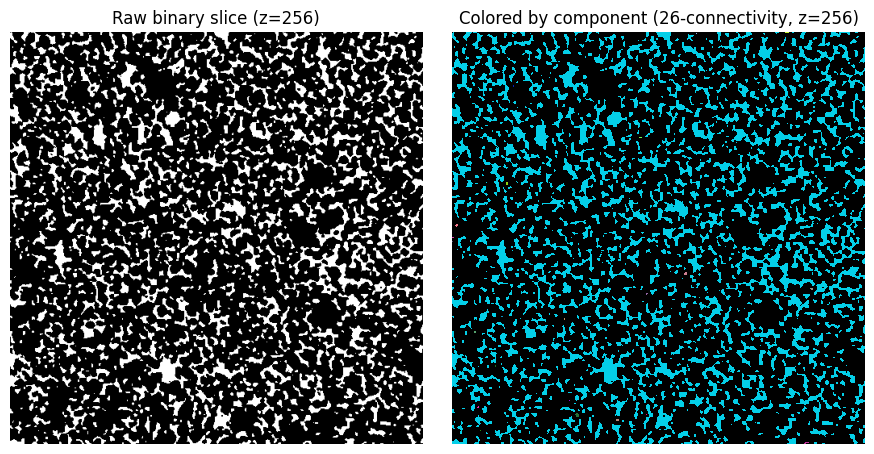

In [5]:
z_mid = img.shape[0] // 2
labels_26 = results[26]['labels']
slice_labels = labels_26[z_mid]
slice_raw = img[z_mid]

n_labels = int(slice_labels.max())
rng = np.random.default_rng(0)
colors = rng.random((n_labels + 1, 3))
colors[0] = 0.0  # background stays black
cmap = ListedColormap(colors)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(slice_raw, cmap="gray")
axes[0].set_title(f"Raw binary slice (z={z_mid})")
axes[0].axis("off")

axes[1].imshow(slice_labels, cmap=cmap, interpolation="nearest")
axes[1].set_title(f"Colored by component (26-connectivity, z={z_mid})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Component-size distribution (26-connectivity)

Log-scale histogram of component voxel counts - real segmented XCT data
typically has a long tail of tiny (often single-voxel) speckle components
alongside a few large ones. Useful for deciding whether the GUI settings
dialog needs a minimum-size filter.

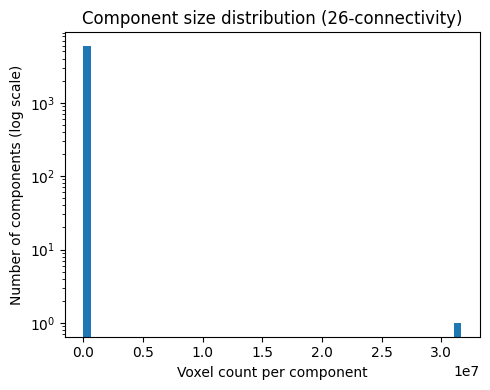

Total components: 5902
Components with <= 5 voxels: 3156


In [6]:
voxel_counts = table_26['voxel_count'].to_numpy()

plt.figure(figsize=(5, 4))
plt.hist(voxel_counts, bins=50, log=True)
plt.xlabel("Voxel count per component")
plt.ylabel("Number of components (log scale)")
plt.title("Component size distribution (26-connectivity)")
plt.tight_layout()
plt.show()

print(f"Total components: {len(voxel_counts)}")
print(f"Components with <= 5 voxels: {int((voxel_counts <= 5).sum())}")

## Synthetic dataset 1: engineered touching-pairs (why connectivity matters)

The real XCT volume above is almost entirely one percolated network, so it can't show what the
connectivity setting actually *does*. Here we build three pairs of 8-voxel cubes, each pair
touching in a different way:

- **Pair 1** - shares a full face -> touching under 6, 18, *and* 26
- **Pair 2** - offset along two axes, shares only a 1-voxel-wide edge -> touching under 18/26, not 6
- **Pair 3** - offset along all three axes, shares only a single corner voxel -> touching only under 26

So going 6 -> 18 -> 26 should merge exactly one extra pair each step: 5 components -> 4 -> 3.

In [7]:
shape = (20, 65, 20)
vol_pairs = np.zeros(shape, dtype=np.uint8)
s = 8  # cube side length

# Pair 1 - face-touching: offset by s along one axis only
vol_pairs[1:1+s,     1:1+s,     1:1+s] = 1
vol_pairs[1+s:1+2*s, 1:1+s,     1:1+s] = 1

# Pair 2 - edge-touching: offset by s along two axes
vol_pairs[1:1+s,     20:20+s,     1:1+s] = 1
vol_pairs[1+s:1+2*s, 20+s:20+2*s, 1:1+s] = 1

# Pair 3 - corner-only touching: offset by s along all three axes
vol_pairs[1:1+s,     45:45+s,     1:1+s] = 1
vol_pairs[1+s:1+2*s, 45+s:45+2*s, 1+s:1+2*s] = 1

print(f"vol_pairs shape: {vol_pairs.shape}, foreground voxels: {int(vol_pairs.sum())}")

vol_pairs shape: (20, 65, 20), foreground voxels: 3072


In [8]:
# One merge should happen per connectivity step: 5 -> 4 -> 3 components.
expected = {6: 5, 18: 4, 26: 3}

for connectivity in (6, 18, 26):
    r = connected_components_3d(vol_pairs, connectivity=connectivity)
    match = "OK" if r['num_components'] == expected[connectivity] else "MISMATCH"
    print(f"connectivity={connectivity:2d}: num_components={r['num_components']} "
          f"(expected {expected[connectivity]}, {match})")

connectivity= 6: num_components=5 (expected 5, OK)
connectivity=18: num_components=4 (expected 4, OK)
connectivity=26: num_components=3 (expected 3, OK)


Note on the plot below: pair 3's two cubes are offset in Z as well as X/Y (that's what makes it a
pure corner touch), so only *one* of its two cubes falls inside any single Z-slice - the other is
one slice away. That's the whole point of needing a connectivity setting in 3D: some adjacencies
are invisible in a single 2D slice but very real in the volume.

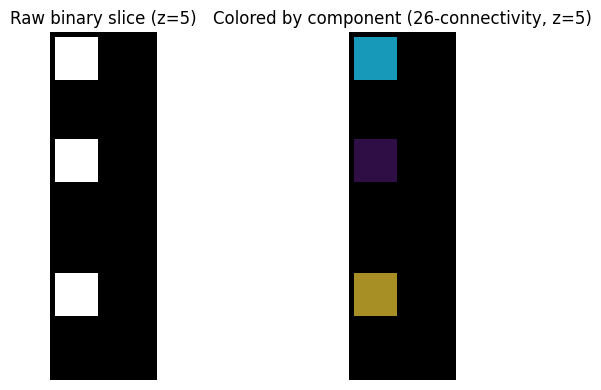

In [9]:
z_slice = 5
labels_pairs = connected_components_3d(vol_pairs, connectivity=26)['labels']
slice_labels = labels_pairs[z_slice]
slice_raw = vol_pairs[z_slice]

n_labels = int(slice_labels.max())
rng = np.random.default_rng(2)
colors = rng.random((n_labels + 1, 3))
colors[0] = 0.0
cmap = ListedColormap(colors)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(slice_raw, cmap="gray")
axes[0].set_title(f"Raw binary slice (z={z_slice})")
axes[0].axis("off")
axes[1].imshow(slice_labels, cmap=cmap, interpolation="nearest")
axes[1].set_title(f"Colored by component (26-connectivity, z={z_slice})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Synthetic dataset 2: separated spheres (clean multi-component picture + volume accuracy check)

Four `skimage.draw.ellipsoid` balls placed far enough apart that they never touch, all centered on
the same Z-slice so a single slice shows all four as separate colors. Since each component is a
copy of the exact same mask, its measured `voxel_count` should match the mask's own voxel count
*exactly* - a stronger check than comparing to the analytic sphere volume, which has some
discretization error of its own.

In [10]:
from skimage.draw import ellipsoid

sphere_mask = ellipsoid(6, 6, 6)  # boolean ball, shape (15, 15, 15)
print(f"sphere_mask shape: {sphere_mask.shape}, voxel count: {int(sphere_mask.sum())}")
print(f"analytic 4/3*pi*r^3 = {4/3*np.pi*6**3:.1f} (discretization difference vs. the mask is expected)")

vol_spheres = np.zeros((30, 60, 60), dtype=np.uint8)  # (Z, Y, X)
half = sphere_mask.shape[0] // 2

centers = [(15, 15, 15), (15, 15, 45), (15, 45, 15), (15, 45, 45)]  # (z, y, x), all same z
for cz, cy, cx in centers:
    vol_spheres[cz-half:cz+half+1, cy-half:cy+half+1, cx-half:cx+half+1] |= sphere_mask

print(f"vol_spheres shape: {vol_spheres.shape}, foreground voxels: {int(vol_spheres.sum())}")

sphere_mask shape: (15, 15, 15), voxel count: 925
analytic 4/3*pi*r^3 = 904.8 (discretization difference vs. the mask is expected)
vol_spheres shape: (30, 60, 60), foreground voxels: 3700


In [11]:
result = connected_components_3d(vol_spheres, connectivity=26, res=1.0)
print(f"num_components: {result['num_components']} (expected {len(centers)})")

exact_match = (result['table']['voxel_count'] == sphere_mask.sum()).all()
print(f"every component's voxel_count matches the sphere mask exactly: {exact_match}")
result['table']

num_components: 4 (expected 4)
every component's voxel_count matches the sphere mask exactly: True


,label,voxel_count,volume
0,1,925.0,925.0
1,2,925.0,925.0
2,3,925.0,925.0
3,4,925.0,925.0


In [12]:
result['num_components']

4

In [13]:
result['table']

,label,voxel_count,volume
0,1,925.0,925.0
1,2,925.0,925.0
2,3,925.0,925.0
3,4,925.0,925.0


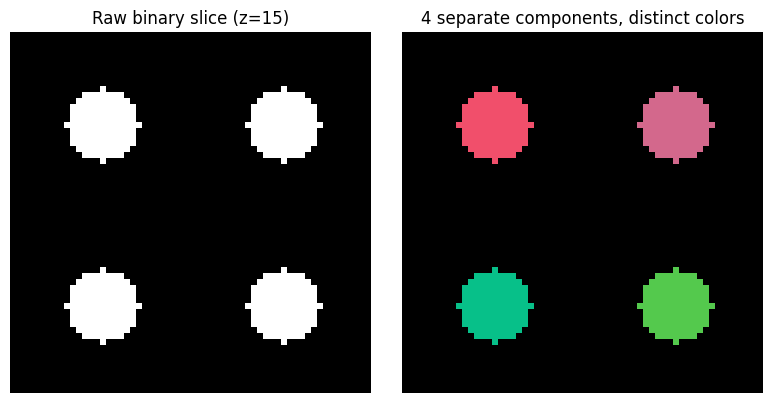

In [14]:
z_slice = 15
labels_spheres = result['labels']
slice_labels = labels_spheres[z_slice]
slice_raw = vol_spheres[z_slice]

n_labels = int(slice_labels.max())
rng = np.random.default_rng(1)
colors = rng.random((n_labels + 1, 3))
colors[0] = 0.0
cmap = ListedColormap(colors)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(slice_raw, cmap="gray")
axes[0].set_title(f"Raw binary slice (z={z_slice})")
axes[0].axis("off")
axes[1].imshow(slice_labels, cmap=cmap, interpolation="nearest")
axes[1].set_title(f"{n_labels} separate components, distinct colors")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Shape measurements: equivalent diameter, aspect ratio, perimeter/circularity

Tests `compute_shape_measurements` - the regionprops-only measurements (no marching-cubes
surface area or eigenvector orientation yet). First on the 4 spheres already built above
(3D: equivalent diameter + aspect ratio), then on a fresh set of four distinctly-shaped 2D
blobs (2D: + perimeter, specific perimeter, circularity) to see the shape metrics actually
differentiate round vs. cornered vs. elongated shapes.

### 3D: equivalent diameter + aspect ratio on the 4 spheres

All 4 components are copies of the same sphere, so `aspect_ratio` should come out close to
1.0 for every one of them, and `equivalent_diameter` should be consistent across all 4 too
(they're identical shapes) and in the right ballpark for a sphere of that voxel count.

In [15]:
from skimage.measure import regionprops
from src.micro_gui.analysis.connected_components import compute_shape_measurements

shape_table_3d = compute_shape_measurements(result['labels'], is_3d=True, res=1.0)
merged_3d = result['table'].merge(shape_table_3d, on='label')
merged_3d[['label', 'voxel_count', 'volume', 'equivalent_diameter', 'aspect_ratio']]

,label,voxel_count,volume,equivalent_diameter,aspect_ratio
0,1,925.0,925.0,12.08874,1.0
1,2,925.0,925.0,12.08874,1.0
2,3,925.0,925.0,12.08874,1.0
3,4,925.0,925.0,12.08874,1.0


In [16]:
r

{'labels': array([[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 1, 1, ..., 0, 0, 0],
         [0, 1, 1, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 1, 1, ..., 0, 0, 0],
         [0, 1, 1, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        ...,
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],
 
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ...,

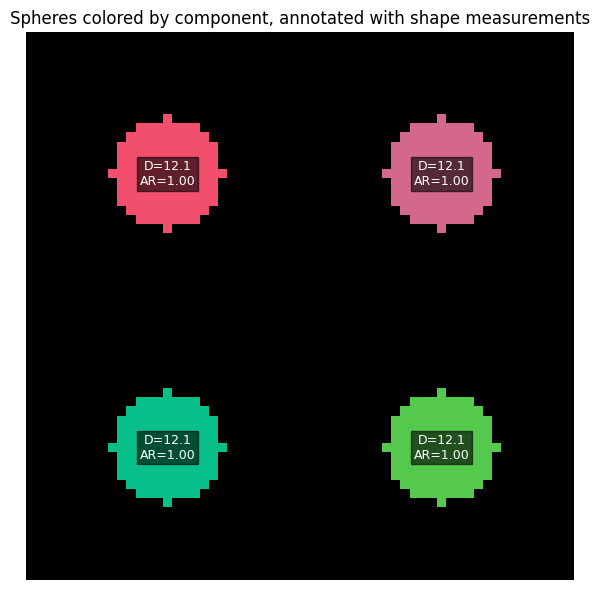

In [17]:
region_lookup_3d = {r.label: r for r in regionprops(labels_spheres)}

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(labels_spheres[15], cmap=cmap, interpolation="nearest")
ax.set_title("Spheres colored by component, annotated with shape measurements")
ax.axis("off")

for _, row in merged_3d.iterrows():
    region = region_lookup_3d[row['label']]
    _, y, x = region.centroid  # (z, y, x) - the displayed slice is the (y, x) plane
    ax.text(x, y, f"D={row['equivalent_diameter']:.1f}\nAR={row['aspect_ratio']:.2f}",
            color="white", ha="center", va="center", fontsize=9,
            bbox=dict(facecolor="black", alpha=0.6, pad=2))

plt.tight_layout()
plt.show()

### 2D: four distinctly-shaped blobs (circle, square, elongated ellipse, L-shape)

Circle is both smooth *and* compact, so it should come out with clearly the highest
circularity. The elongated ellipse is smooth but far from compact - circularity
(`4*pi*Area/Perimeter^2`) penalizes elongation just as much as it penalizes corners, so a
shape with zero corners can still score lower than a cornered-but-compact one once it's
stretched enough. That's why `aspect_ratio` and `circularity` are usually read together
rather than circularity alone: `aspect_ratio` isolates elongation specifically, while
`circularity` captures overall compactness (corners AND elongation combined).

Note: `regionprops`' `perimeter` is a discrete boundary-length approximation, not an exact
geometric one - at these pixel sizes it's normal for circularity to land somewhere in the
0.8-0.95 range for a smooth, compact curve rather than exactly 1.0.

In [18]:
from skimage.draw import disk, ellipse
from src.micro_gui.analysis.connected_components import connected_components_2d

img2d = np.zeros((100, 400), dtype=np.uint8)
rr, cc = disk((50, 50), 30); img2d[rr, cc] = 1                      # circle
img2d[20:80, 130:190] = 1                                            # square
rr, cc = ellipse(50, 260, 15, 60); img2d[rr, cc] = 1                  # elongated ellipse
img2d[20:80, 340:370] = 1; img2d[50:80, 340:400] = 1                  # L-shape

result_2d = connected_components_2d(img2d, connectivity=8, res=1.0)
shape_table_2d = compute_shape_measurements(result_2d['labels'], is_3d=False, res=1.0)
merged_2d = result_2d['table'].merge(shape_table_2d, on='label')

print(f"num_components: {result_2d['num_components']} (expected 4)")

# Label ids are assigned in raster-scan order, not the order the shapes were
# drawn in - match each label back to the shape we intended by nearest centroid.
intended_centers = {'circle': (50, 50), 'square': (50, 160), 'ellipse': (50, 260), 'L-shape': (50, 365)}
region_lookup_2d = {r.label: r for r in regionprops(result_2d['labels'])}

def nearest_shape_name(label):
    cy, cx = region_lookup_2d[label].centroid
    return min(intended_centers, key=lambda name: (intended_centers[name][0]-cy)**2 + (intended_centers[name][1]-cx)**2)

merged_2d['shape'] = merged_2d['label'].apply(nearest_shape_name)
merged_2d = merged_2d.set_index('shape').loc[['circle', 'square', 'ellipse', 'L-shape']].reset_index()
merged_2d[['shape', 'label', 'pixel_count', 'area', 'aspect_ratio', 'circularity', 'perimeter', 'specific_perimeter']]

num_components: 4 (expected 4)


,shape,label,pixel_count,area,aspect_ratio,circularity,perimeter,specific_perimeter
0,circle,3,2809.0,2809.0,1.000000,0.932995,194.509668,0.069245
1,square,1,3600.0,3600.0,1.000000,0.812247,236.000000,0.065556
2,ellipse,4,2795.0,2795.0,4.038650,0.504396,263.882251,0.094412
3,L-shape,2,2700.0,2700.0,1.464036,0.612221,235.414214,0.087190


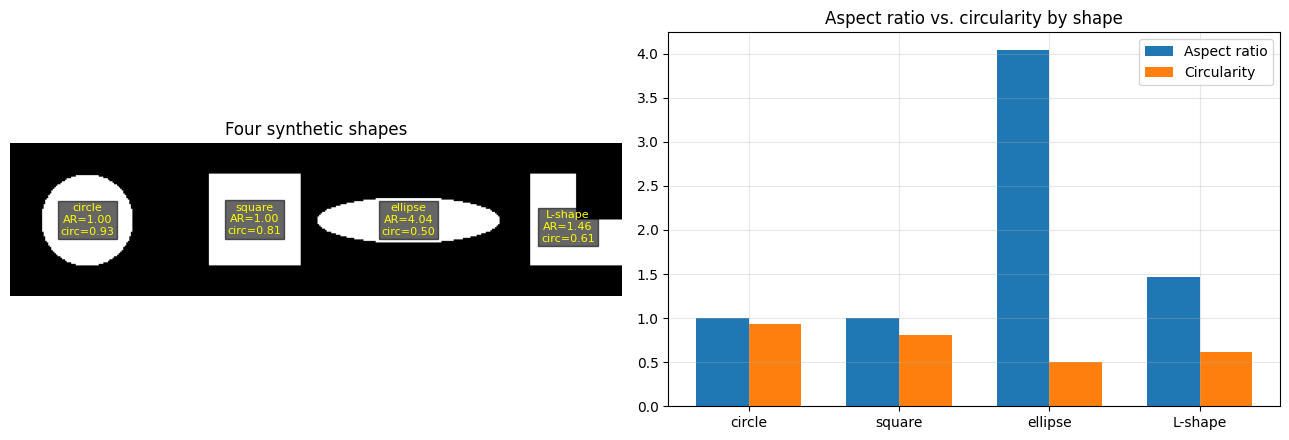

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].imshow(img2d, cmap="gray")
axes[0].set_title("Four synthetic shapes")
axes[0].axis("off")
for _, row in merged_2d.iterrows():
    region = region_lookup_2d[row['label']]
    cy, cx = region.centroid
    axes[0].text(cx, cy, f"{row['shape']}\nAR={row['aspect_ratio']:.2f}\ncirc={row['circularity']:.2f}",
                 color="yellow", ha="center", va="center", fontsize=8,
                 bbox=dict(facecolor="black", alpha=0.6, pad=2))

x = np.arange(len(merged_2d))
width = 0.35
axes[1].bar(x - width/2, merged_2d['aspect_ratio'], width, label='Aspect ratio')
axes[1].bar(x + width/2, merged_2d['circularity'], width, label='Circularity')
axes[1].set_xticks(x)
axes[1].set_xticklabels(merged_2d['shape'])
axes[1].set_title("Aspect ratio vs. circularity by shape")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Advanced 3D shape measurements: surface area, sphericity, elongation/flatness, orientation

Tests `compute_advanced_shape_measurements` - the marching-cubes/eigenvector-based
measurements. Five synthetic shapes with known, distinct geometry: a sphere (control - should
score sphericity/elongation/flatness all near 1), a flattened disc (low flatness), and three
identical rods, each elongated along a different array axis (low elongation, but each should
report a different inclination/azimuth orientation - the whole reason this needs an eigenvector, not
just an eigenvalue).

In [20]:
shapes_info = [
    ('sphere', ellipsoid(8, 8, 8)),
    ('disc (flat along X)', ellipsoid(8, 8, 2)),
    ('rod along Z', ellipsoid(15, 3, 3)),
    ('rod along Y', ellipsoid(3, 15, 3)),
    ('rod along X', ellipsoid(3, 3, 15)),
]

# All 5 shapes share the same (z, y) center and sit side by side along x - each
# shape's own half-width (from its mask shape) sets how much x-room it needs,
# so nothing overlaps regardless of how differently sized the shapes are.
max_zy = max(max(mask.shape[0], mask.shape[1]) for _, mask in shapes_info)
vol_shape_z = max_zy + 4
vol_shape_y = max_zy + 4

x_positions = []
x_cursor = 5
for name, mask in shapes_info:
    half_x = mask.shape[2] // 2
    x_cursor += half_x
    x_positions.append(x_cursor)
    x_cursor += half_x + 10
vol_shape_x = x_cursor

vol_advanced = np.zeros((vol_shape_z, vol_shape_y, vol_shape_x), dtype=np.uint8)
cz, cy = vol_shape_z // 2, vol_shape_y // 2

for (name, mask), cx in zip(shapes_info, x_positions):
    hz, hy, hx = mask.shape[0] // 2, mask.shape[1] // 2, mask.shape[2] // 2
    vol_advanced[cz-hz:cz+hz+1, cy-hy:cy+hy+1, cx-hx:cx+hx+1] |= mask

print(f"vol_advanced shape: {vol_advanced.shape}, foreground voxels: {int(vol_advanced.sum())}")

vol_advanced shape: (37, 37, 127), foreground voxels: 4287


In [21]:
from src.micro_gui.analysis.connected_components import compute_advanced_shape_measurements

result_advanced = connected_components_3d(vol_advanced, connectivity=26, res=1.0)
print(f"num_components: {result_advanced['num_components']} (expected 5)")

requested = ['surface_area', 'specific_surface_area', 'sphericity', 'elongation', 'flatness', 'inclination_deg', 'azimuth_deg']
advanced_table = compute_advanced_shape_measurements(result_advanced['labels'], res=1.0, requested=requested)
merged_advanced = result_advanced['table'].merge(advanced_table, on='label')

# Match each label back to the shape we intended, by nearest centroid - same
# reasoning as the 2D shapes section above: label ids come from raster-scan
# order, not the order the shapes were placed in.
region_lookup_advanced = {r.label: r for r in regionprops(result_advanced['labels'])}
intended_centers_advanced = {name: (cz, cy, cx) for (name, mask), cx in zip(shapes_info, x_positions)}

def nearest_shape_name_3d(label):
    c = region_lookup_advanced[label].centroid
    return min(intended_centers_advanced, key=lambda name: sum((a - b) ** 2 for a, b in zip(intended_centers_advanced[name], c)))

merged_advanced['shape'] = merged_advanced['label'].apply(nearest_shape_name_3d)
merged_advanced = merged_advanced.set_index('shape').loc[[name for name, _ in shapes_info]].reset_index()
merged_advanced[['shape', 'sphericity', 'elongation', 'flatness', 'inclination_deg', 'azimuth_deg']]

num_components: 5 (expected 5)


,shape,sphericity,elongation,flatness,inclination_deg,azimuth_deg
0,sphere,0.922825,1.000000,1.000000,0.0,0.0
1,disc (flat along X),0.638510,1.000000,0.215246,0.0,0.0
2,rod along Z,0.664308,0.186216,1.000000,0.0,0.0
3,rod along Y,0.664308,0.186216,1.000000,90.0,90.0
4,rod along X,0.664308,0.186216,1.000000,90.0,0.0


Sanity check on the numbers above: the sphere should have sphericity near 1 and
elongation/flatness both near 1 (no preferred axis). The disc should have flatness well
below 1 (it's thin along one axis). All three rods should have the *same* low elongation
(they're the same shape, just reoriented) but *different* orientations. Inclination is the
angle from Z (0 = points along Z, 90 = lies flat in the slice plane) and azimuth is the
in-plane direction from X+, so expect inclination/azimuth of 0/0 for the Z-aligned rod,
90/90 for the Y-aligned rod, and 90/0 for the X-aligned rod.

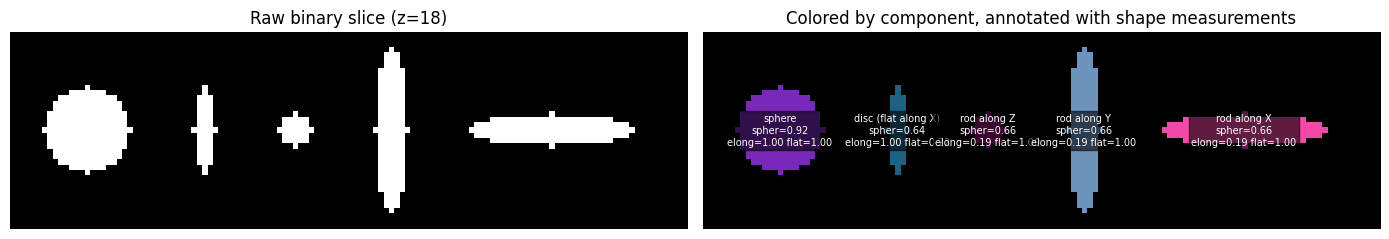

In [22]:
z_slice = cz
labels_advanced = result_advanced['labels']
slice_labels = labels_advanced[z_slice]
slice_raw = vol_advanced[z_slice]

n_labels = int(slice_labels.max())
rng = np.random.default_rng(3)
colors = rng.random((n_labels + 1, 3))
colors[0] = 0.0
cmap_advanced = ListedColormap(colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(slice_raw, cmap="gray")
axes[0].set_title(f"Raw binary slice (z={z_slice})")
axes[0].axis("off")

axes[1].imshow(slice_labels, cmap=cmap_advanced, interpolation="nearest")
axes[1].set_title("Colored by component, annotated with shape measurements")
axes[1].axis("off")

for _, row in merged_advanced.iterrows():
    region = region_lookup_advanced[row['label']]
    _, y, x = region.centroid  # (z, y, x) - the displayed slice is the (y, x) plane
    axes[1].text(
        x, y, f"{row['shape']}\nspher={row['sphericity']:.2f}\nelong={row['elongation']:.2f} flat={row['flatness']:.2f}",
        color="white", ha="center", va="center", fontsize=7,
        bbox=dict(facecolor="black", alpha=0.6, pad=2)
    )

plt.tight_layout()
plt.show()

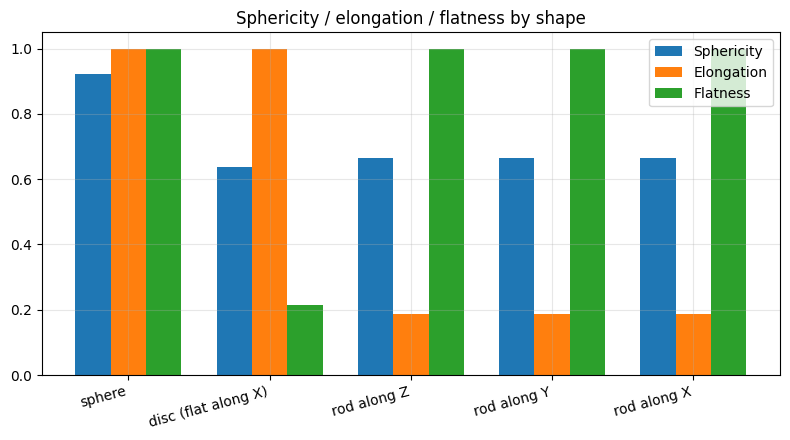

In [23]:
x = np.arange(len(merged_advanced))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width, merged_advanced['sphericity'], width, label='Sphericity')
ax.bar(x, merged_advanced['elongation'], width, label='Elongation')
ax.bar(x + width, merged_advanced['flatness'], width, label='Flatness')
ax.set_xticks(x)
ax.set_xticklabels(merged_advanced['shape'], rotation=15, ha='right')
ax.set_title("Sphericity / elongation / flatness by shape")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()